In [5]:
from pathlib import Path
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

dataset_dir = Path("hyperface/ds007329")

for subject_dir in sorted(dataset_dir.glob("sub-*")):

    subject = subject_dir.name
    print(f"\nProcessing {subject}")

    events_file = subject_dir / "ses-1" / "func" / f"{subject}_ses-1_task-localizer_run-01_events.tsv"
    events_05_file = subject_dir / "ses-1" / "func" / f"{subject}_ses-1_task-localizer_run-05_events.tsv"

    events = pd.read_csv(events_file, sep="\t")
    events_05 = pd.read_csv(events_05_file, sep="\t")

    print("Run 01:", events.shape)
    print("Run 05:", events_05.shape)


Processing sub-sid000005
Run 01: (69, 5)
Run 05: (66, 5)

Processing sub-sid000007
Run 01: (66, 5)
Run 05: (66, 5)

Processing sub-sid000009
Run 01: (67, 5)
Run 05: (67, 5)

Processing sub-sid000010
Run 01: (70, 5)
Run 05: (68, 5)

Processing sub-sid000013
Run 01: (68, 5)
Run 05: (70, 5)

Processing sub-sid000020
Run 01: (63, 5)
Run 05: (70, 5)

Processing sub-sid000021
Run 01: (68, 5)
Run 05: (69, 5)

Processing sub-sid000024
Run 01: (68, 5)
Run 05: (68, 5)

Processing sub-sid000029
Run 01: (66, 5)
Run 05: (67, 5)

Processing sub-sid000034
Run 01: (67, 5)
Run 05: (68, 5)

Processing sub-sid000052
Run 01: (67, 5)
Run 05: (66, 5)

Processing sub-sid000114
Run 01: (67, 5)
Run 05: (65, 5)

Processing sub-sid000120
Run 01: (67, 5)
Run 05: (68, 5)

Processing sub-sid000134
Run 01: (69, 5)
Run 05: (68, 5)

Processing sub-sid000142
Run 01: (68, 5)
Run 05: (68, 5)

Processing sub-sid000278
Run 01: (69, 5)
Run 05: (66, 5)

Processing sub-sid000416
Run 01: (69, 5)
Run 05: (68, 5)

Processing su

In [6]:
exclude = ["button_press", "fixation"]

condition_events = events[~events["stim_type"].isin(exclude)].copy()
condition_events_05 = events_05[~events_05["stim_type"].isin(exclude)].copy()

unique_conditions = condition_events["stim_type"].unique()
conditions = condition_events["stim_type"].values

print(unique_conditions)

['objects' 'bodies' 'scenes' 'scrambled_objects' 'faces']


In [7]:
print(condition_events["stim_type"].value_counts())

stim_type
objects              12
bodies               12
scenes               12
scrambled_objects    12
faces                12
Name: count, dtype: int64


In [8]:
events_glm = condition_events.rename(columns={"stim_type": "trial_type"})
display(events_glm.head())

events_glm_05 = condition_events_05.rename(columns={"stim_type": "trial_type"})

,onset,duration,trial_type,video_file,repetition
1,18.000,3.0,objects,stimuli/objects/balls.mp4,0
2,21.004,3.0,objects,stimuli/objects/flag.mp4,0
3,24.016,3.0,objects,stimuli/objects/obj_17.mp4,0
4,27.029,3.0,objects,stimuli/objects/obj_17.mp4,1
6,30.041,3.0,objects,stimuli/objects/digital_mixer.mp4,0


In [9]:
import nibabel as nib
import numpy as np
from pathlib import Path
from nilearn import image
from nilearn.masking import intersect_masks
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix

dataset_dir = Path("hyperface/ds007384")
subject_results = {}

for subject_dir in sorted(dataset_dir.glob("sub-*")):
    if not subject_dir.is_dir():
        continue

    subject = subject_dir.name

    func_file = subject_dir / "ses-1" / "func" / f"{subject}_ses-1_task-localizer_run-01_space-T1w_desc-preproc_bold.nii.gz"
    mask_file = subject_dir / "ses-1" / "func" / f"{subject}_ses-1_task-localizer_run-01_space-T1w_desc-brain_mask.nii.gz"
    func_file_05 = subject_dir / "ses-1" / "func" / f"{subject}_ses-1_task-localizer_run-05_space-T1w_desc-preproc_bold.nii.gz"
    mask_file_05 = subject_dir / "ses-1" / "func" / f"{subject}_ses-1_task-localizer_run-05_space-T1w_desc-brain_mask.nii.gz"

    if not all(file.exists() for file in [func_file, mask_file, func_file_05, mask_file_05]):
        print(f"{subject}: run-01 or run-05 file not found")
        continue

    print(f"\nProcessing {subject}")

    try:
        img = nib.load(func_file)
        img_05 = nib.load(func_file_05)

        n_trs = img.shape[-1]
        n_trs_05 = img_05.shape[-1]
        tr = img.header.get_zooms()[3]
        tr_05 = img_05.header.get_zooms()[3]

        print(f"{subject}: run-01 = {n_trs} TRs, run-05 = {n_trs_05} TRs")

        frame_times = np.arange(n_trs) * tr
        frame_times_05 = np.arange(n_trs_05) * tr_05

        design_matrix = make_first_level_design_matrix(
            frame_times,
            events_glm,
            drift_model="cosine",
            high_pass=0.008,
            hrf_model="glover"
        )

        design_matrix_05 = make_first_level_design_matrix(
            frame_times_05,
            events_glm_05,
            drift_model="cosine",
            high_pass=0.008,
            hrf_model="glover"
        )

        combined_mask = intersect_masks(
            [mask_file, mask_file_05],
            threshold=1,
            connected=False
        )

        glm = FirstLevelModel(
            mask_img=combined_mask,
            smoothing_fwhm=4,
            subject_label=subject
        )

        glm = glm.fit(
            [func_file, func_file_05],
            design_matrices=[design_matrix, design_matrix_05]
        )

        mean_img_ = image.mean_img([func_file, func_file_05], copy_header=True)

        subject_results[subject] = {
            "glm": glm,
            "mean_img": mean_img_,
            "design_matrices": [design_matrix, design_matrix_05],
            "func_files": [func_file, func_file_05],
            "mask_img": combined_mask,
            "trs": [tr, tr_05],
            "n_trs": [n_trs, n_trs_05]
        }

        print(f"{subject}: GLM fitted with run-01 and run-05")

    except Exception as error:
        print(f"{subject}: GLM ERROR")
        print(f"{type(error).__name__}: {error}")
        continue

print(f"\nTotal subjects found: {len([x for x in dataset_dir.glob('sub-*') if x.is_dir()])}")
print(f"Total GLMs saved: {len(subject_results)}")
print(list(subject_results.keys()))


Processing sub-sid000005
sub-sid000005: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000005: GLM fitted with run-01 and run-05

Processing sub-sid000007
sub-sid000007: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000007: GLM fitted with run-01 and run-05

Processing sub-sid000009
sub-sid000009: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000009: GLM fitted with run-01 and run-05

Processing sub-sid000010
sub-sid000010: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000010: GLM fitted with run-01 and run-05

Processing sub-sid000013
sub-sid000013: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000013: GLM fitted with run-01 and run-05

Processing sub-sid000020
sub-sid000020: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000020: GLM fitted with run-01 and run-05

Processing sub-sid000021
sub-sid000021: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000021: GLM fitted with run-01 and run-05

Processing sub-sid000024
sub-sid000024: run-01 = 236 TRs, run-05 = 236 TRs
sub-sid000024: GLM fitted with run-01 and run-05


In [15]:
from pathlib import Path
import subprocess
from templateflow.api import get

fmri_dataset = Path("hyperface/ds007384")
t1_maps_dir = Path("hyperface/first_level_T1w")
mni_maps_dir = Path("hyperface/first_level_MNI")

t1_maps_dir.mkdir(exist_ok=True)
mni_maps_dir.mkdir(exist_ok=True)

mni_template = get("MNI152NLin2009cAsym", resolution=2, desc=None, suffix="T1w", extension="nii.gz")

for subject, result in subject_results.items():
    subject_dir = fmri_dataset / subject
    xfm_file = next(subject_dir.glob("ses-budapest/anat/*from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5"), None)

    if xfm_file is None:
        print(f"{subject}: transformation not found")
        continue

    for condition in unique_conditions:
        effect_map = result["glm"].compute_contrast(condition, output_type="effect_size")

        t1_file = t1_maps_dir / f"{subject}_{condition}_effect_size_T1w.nii.gz"
        mni_file = mni_maps_dir / f"{subject}_{condition}_effect_size_MNI.nii.gz"

        effect_map.to_filename(t1_file)

        subprocess.run([
            "antsApplyTransforms",
            "-d", "3",
            "-i", str(t1_file),
            "-r", str(mni_template),
            "-o", str(mni_file),
            "-n", "Linear",
            "-t", str(xfm_file)
        ], check=True)

        print(f"{subject}: {condition} transformed to MNI")

sub-sid000005: objects transformed to MNI
sub-sid000005: bodies transformed to MNI
sub-sid000005: scenes transformed to MNI
sub-sid000005: scrambled_objects transformed to MNI
sub-sid000005: faces transformed to MNI
sub-sid000007: objects transformed to MNI
sub-sid000007: bodies transformed to MNI
sub-sid000007: scenes transformed to MNI
sub-sid000007: scrambled_objects transformed to MNI
sub-sid000007: faces transformed to MNI
sub-sid000009: objects transformed to MNI
sub-sid000009: bodies transformed to MNI
sub-sid000009: scenes transformed to MNI
sub-sid000009: scrambled_objects transformed to MNI
sub-sid000009: faces transformed to MNI
sub-sid000010: objects transformed to MNI
sub-sid000010: bodies transformed to MNI
sub-sid000010: scenes transformed to MNI
sub-sid000010: scrambled_objects transformed to MNI
sub-sid000010: faces transformed to MNI
sub-sid000013: objects transformed to MNI
sub-sid000013: bodies transformed to MNI
sub-sid000013: scenes transformed to MNI
sub-sid00001

In [17]:
import numpy as np
import pandas as pd
from nilearn.glm.second_level import SecondLevelModel

group_reports_dir = Path("hyperface/group_reports")
group_reports_dir.mkdir(exist_ok=True)

group_results = {}

for condition in unique_conditions:
    contrast_maps = [
        mni_maps_dir / f"{subject}_{condition}_effect_size_MNI.nii.gz"
        for subject in sorted(subject_results)
    ]

    contrast_maps = [str(file) for file in contrast_maps if file.exists()]
    print(f"\n{condition}: {len(contrast_maps)} subjects")

    group_design = pd.DataFrame({
        "intercept": np.ones(len(contrast_maps))
    })

    group_model = SecondLevelModel(smoothing_fwhm=6)
    group_model = group_model.fit(
        contrast_maps,
        design_matrix=group_design)

    z_map = group_model.compute_contrast(
        second_level_contrast="intercept",
        output_type="z_score")

    z_map.to_filename(
        group_reports_dir / f"group_{condition}_zmap.nii.gz")

    report = group_model.generate_report(
        contrasts="intercept",
        bg_img=mni_template,
        title=f"Group analysis: {condition}",
        height_control="fdr",
        alpha=0.05)

    report.save_as_html(
        group_reports_dir / f"group_{condition}_report.html")

    group_results[condition] = {
        "model": group_model,
        "z_map": z_map}

    print(f"{condition}: group report saved")


objects: 21 subjects
objects: group report saved

bodies: 21 subjects
bodies: group report saved

scenes: 21 subjects
scenes: group report saved

scrambled_objects: 21 subjects
scrambled_objects: group report saved

faces: 21 subjects
faces: group report saved


In [20]:
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path
from templateflow.api import get
from nilearn import image
from nilearn.glm.second_level import SecondLevelModel

mni_mask = get("MNI152NLin2009cAsym", resolution=2, desc="brain", suffix="mask", extension="nii.gz")
mni_mask_binary = image.math_img("img > 0.5", img=str(mni_mask))

print("Voxels in binary mask:", np.count_nonzero(mni_mask_binary.get_fdata()))

group_reports_dir = Path("Grand_Budapest_Hotel_study/group_reports_custom_binary_mask")
group_reports_dir.mkdir(parents=True, exist_ok=True)
group_results = {}

for contrast_name in custom_contrasts:
    contrast_maps = [mni_maps_dir / f"{subject}_{contrast_name}_effect_size_MNI.nii.gz" for subject in sorted(subject_results)]
    contrast_maps = [str(file) for file in contrast_maps if file.exists()]
    print(f"\nGroup {contrast_name}: {len(contrast_maps)} subjects")

    group_design = pd.DataFrame({"intercept": np.ones(len(contrast_maps))})
    group_model = SecondLevelModel(mask_img=mni_mask_binary, smoothing_fwhm=6)
    group_model = group_model.fit(contrast_maps, design_matrix=group_design)

    z_map = group_model.compute_contrast(second_level_contrast="intercept", output_type="z_score")
    z_map.to_filename(group_reports_dir / f"group_{contrast_name}_zmap.nii.gz")

    report = group_model.generate_report(
        contrasts="intercept",
        bg_img=mni_template,
        title=f"Group analysis: {contrast_name}",
        height_control="fdr",
        alpha=0.05
    )

    report.save_as_html(group_reports_dir / f"group_{contrast_name}_report.html")
    group_results[contrast_name] = {"model": group_model, "z_map": z_map}
    print(f"{contrast_name}: group report saved")

Voxels in binary mask: 235840

Group objects_vs_scenes: 21 subjects
objects_vs_scenes: group report saved

Group faces_vs_objects: 21 subjects
faces_vs_objects: group report saved

Group objects_vs_scrambled: 21 subjects
objects_vs_scrambled: group report saved

Group animacy: 21 subjects
animacy: group report saved


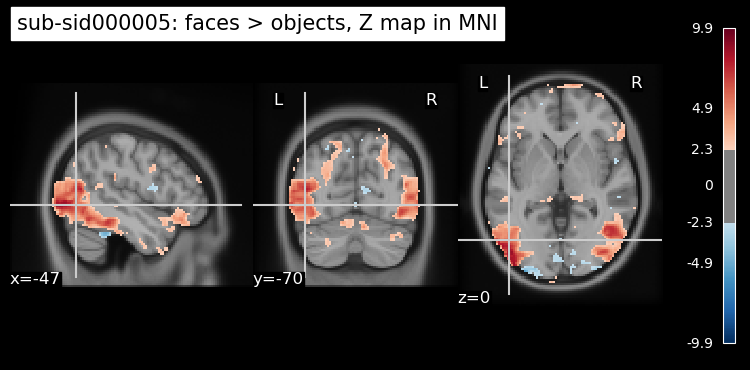

In [34]:
import subprocess
from pathlib import Path
from nilearn import plotting

subject = "sub-sid000005"
contrast = "faces - objects"

subject_dir = fmri_dataset / subject
xfm_file = next(subject_dir.glob("ses-budapest/anat/*from-T1w_to-MNI152NLin2009cAsym_mode-image_xfm.h5"))

z_map_t1 = subject_results[subject]["glm"].compute_contrast(
    contrast,
    output_type="z_score"
)

z_t1_file = t1_maps_dir / f"{subject}_faces_vs_objects_zscore_T1w.nii.gz"
z_mni_file = mni_maps_dir / f"{subject}_faces_vs_objects_zscore_MNI.nii.gz"

z_map_t1.to_filename(z_t1_file)

subprocess.run([
    "antsApplyTransforms",
    "-d", "3",
    "-i", str(z_t1_file),
    "-r", str(mni_template),
    "-o", str(z_mni_file),
    "-n", "Linear",
    "-t", str(xfm_file)
], check=True)

plotting.plot_stat_map(
    str(z_mni_file),
    bg_img=mni_template,
    threshold=2.3,
    symmetric_cbar=True,
    title=f"{subject}: faces > objects, Z map in MNI"
)

plotting.show()